# Hernquist distribution
The aim of this notebook is to generate an unperturbed Hernquist distribution. We will then add two extra points which will simulate two black holes, to study the dynamical friction and their interaction.

The Henrquist profile is described by the follwing density distribution:

$$ \rho(r) = \frac{M}{2\pi}\frac{a}{r}\frac{1}{(r+a)^3} $$   
where $a$ is a scale radius. Note that for radii larger than $a$, the density goes as $r^{-4}$, at smaller radii it will instead go as r.

From the density distribution one can compute the mass distribution and the potential shape, assuming a spherical distribution. 

$$ M(R) = \int_0^R 4\pi r^2 \rho(r) dr  = \frac{M_{tot}R^2}{(R+a)^2}$$

$$ \phi_H (R) = -4\pi G\Bigl[\frac{1}{R} \int_0^R \rho(r) r^2 dr + \int_R^\infty \rho(r) r dr\Bigr] = - \frac{GM}{(R+a)}$$

In [1]:
#pip install scienceplots

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import scienceplots
plt.style.use(['science', 'no-latex'])

## Initialization

In [3]:
n = 5000 #number of particles
a = 1 #scale radius
M = 1 #each particle has a mass = M/n in internal units
n_dim = 3

## Position sampling
In order to create the profile, we need to sample the position and velociy of each of our n particles. To do this, we first find the radial distribution:

$$ P(R) = \frac{M(R)}{M_{tot}} = \frac{R^2}{(R + a)^2} $$

where $0 < P(R) < 1$. In this way we can sample from a uniform distribution and then convert that value into a radius:

$$ R = \frac{a\sqrt{P(R)}}{1-\sqrt{P(R)}}$$

Assuming spherical symmetry, the angular positions can instead be generated from:


$$ \Theta = \arccos{(1-2P(\Theta))}$$

$$ \Phi = {2\pi}P(\Phi)$$

where P once again is drawn from a uniform distribution.

In [4]:
def radius_from_P (P):
    return (a * np.sqrt(P)) / (1 - np.sqrt(P))

In [5]:
#samples ---------------------------------
P_R = np.random.uniform(0, 1, n)
radius = radius_from_P (P_R)
radius_s = np.sort(radius)
r_inverse = radius_s[::-1] #we will need the arr that goes from rmax to rmin later

P_theta = np.random.uniform(0, 1, n)
theta = np.arccos(1 - 2*P_theta)

P_phi = np.random.uniform(0, 1, n)
phi = 2 * np.pi * P_phi

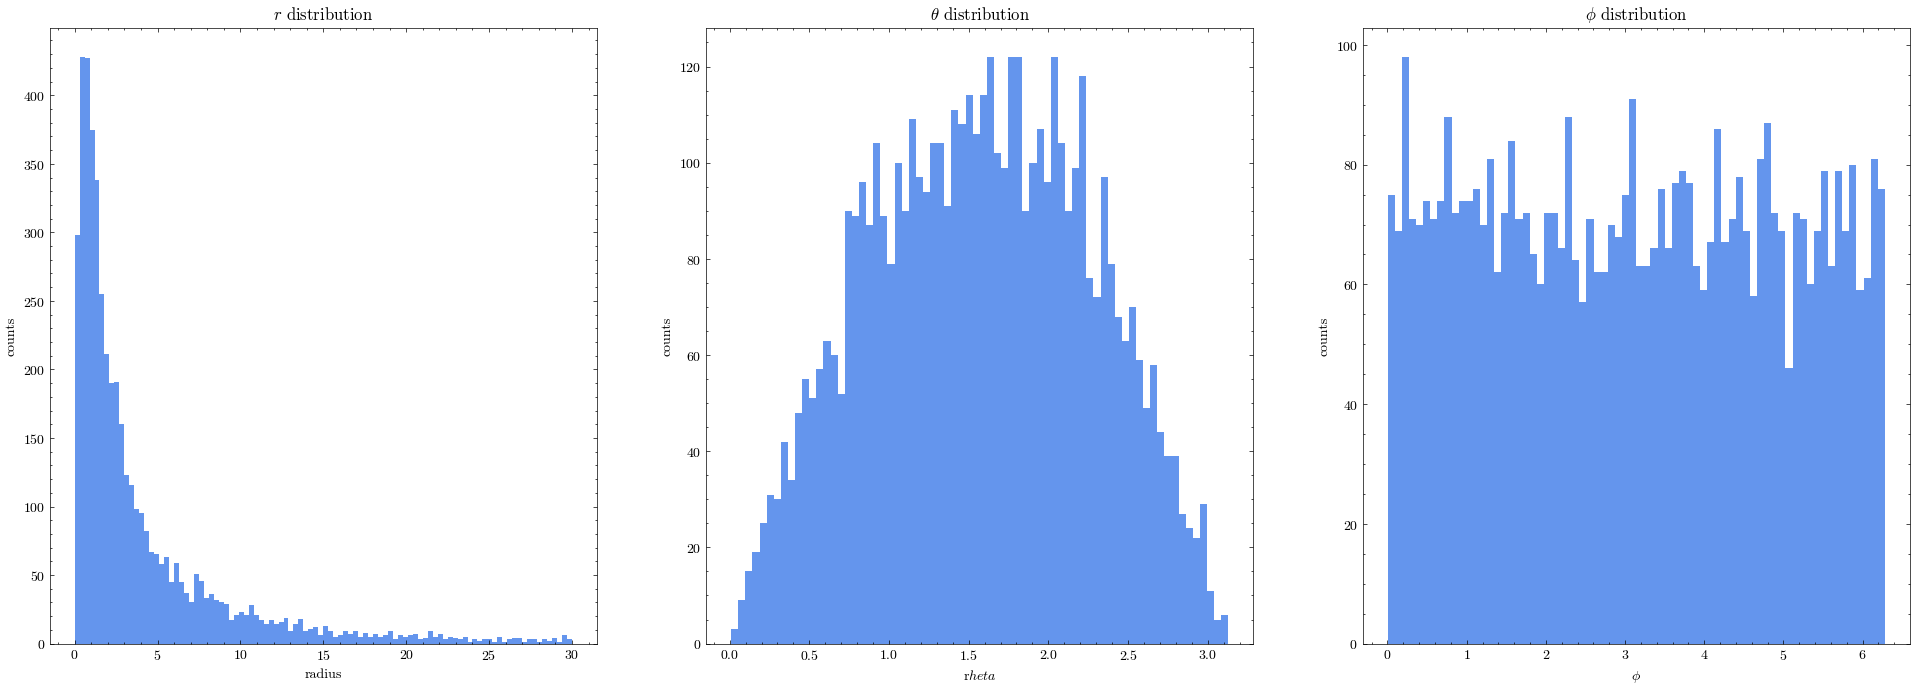

In [6]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(radius_s, range=(0,30), bins = 100, color = 'cornflowerblue')
ax[0].set(title = '$r$ distribution', ylabel = "counts", xlabel = "radius")

ax[1].hist(theta, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[1].set(title = r'$\theta$ distribution', ylabel = "counts", xlabel = 'r$\theta$')
ax[1].plot()

ax[2].hist(phi, bins = int(np.sqrt(n)), color = 'cornflowerblue')
ax[2].set(title = '$\phi$ distribution', ylabel = "counts", xlabel = "$\phi$")
ax[2].plot()

plt.show()

In [7]:
#carthesian coord conversion -----------
def sph_to_carth (radius, theta, phi):
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z

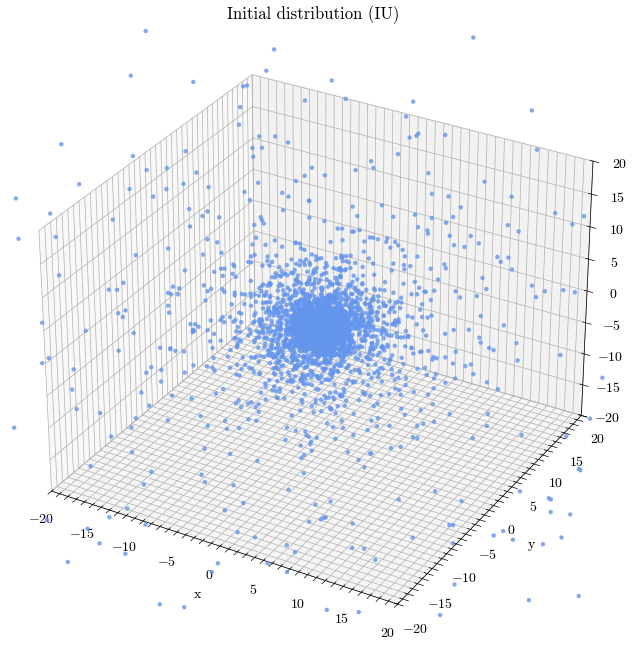

In [8]:
x, y, z = sph_to_carth(radius_s, theta, phi)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.scatter(x,y,z,s=5,alpha=0.7, color = 'cornflowerblue')
ax.set (title = 'Initial distribution (IU)', xlabel = 'x', ylabel = 'y', zlabel = 'z', xlim = (-20,20), ylim = (-20, 20), zlim = (-20, 20))

plt.show()

## Density check

In [9]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

In [10]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    
    for i in range(n_check-1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 1:
            grid_centres.append(float(grid[i+1]))
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid_centres[len(grid_centres)-2]**3)
            rho.append( (M/n) * (dn/dV) )
    
    return rho, grid_centres

In [11]:
num_rho, rho_grid = numerical_density(radius_s, 500)

analytical_rho = [compute_rho(rg) for rg in rho_grid]

/tmp/ipykernel_874/2502167543.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  rho.append( (M/n) * (dn/dV) )


[]

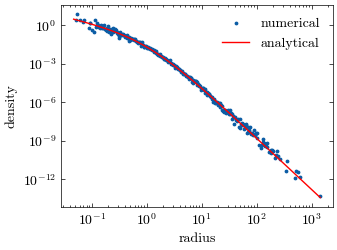

In [12]:
plt.scatter(rho_grid, num_rho, s = 3, label ='numerical')
plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
plt.xlabel('radius')
plt.ylabel('density')
plt.legend()
plt.loglog()

## Velocity sampling

In [13]:
def distribution_function(eps):
    factor = 1/(8 * np.sqrt(2) * np.pi**3)
    term_1 = (np.sqrt(eps) * (1 - 2*eps) * (8*eps**2 -8*eps -3)) / (1 - eps)**2
    term_2 = (3 * np.arcsin(np.sqrt(eps))) / (1-eps)**2.5
    return factor * (term_1 + term_2)
    

def compute_potential(radius):
    return - M / (radius + a)

def v_escape(radius):
    return np.sqrt(- 2 * compute_potential(radius))

<function matplotlib.pyplot.show(close=None, block=None)>

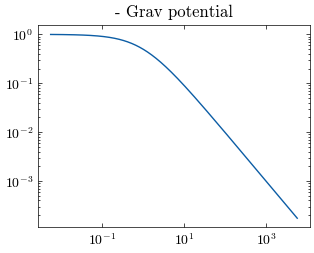

In [14]:
potential = - compute_potential(r_inverse)

plt.plot(r_inverse, potential)
plt.title('- Grav potential')
plt.loglog()
plt.show

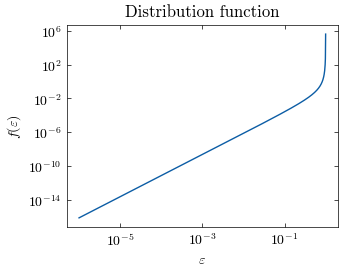

In [15]:
eps_values = np.geomspace(0.000001, 0.999, 1000)
f_values = distribution_function(eps_values)

norm = np.trapezoid(f_values, eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Distribution function')
plt.loglog()
plt.show()

In [16]:
print(norm)

2923.6225441007473


In [17]:
def df_norm(eps):
    return distribution_function(eps)/norm

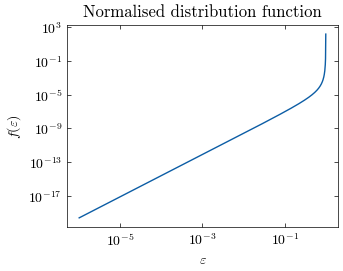

In [18]:
eps_values = np.geomspace(0.000001, 0.999, 1000)
f_values = df_norm(eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Normalised distribution function')
plt.loglog()
plt.show()

In [19]:
from tqdm import tqdm

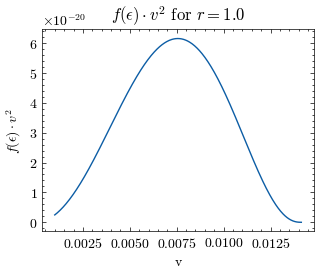

In [20]:
r=1E+4
phi_r = compute_potential(r)
v_max = v_escape(r)

v_vals = np.linspace(0.001, v_max, 500)
epsilon_vals = -(0.5 * v_vals**2 + phi_r)
f_v = df_norm(epsilon_vals) * v_vals**2

plt.plot(v_vals, f_v)
plt.xlabel("v")
plt.ylabel(r"$f(\epsilon) \cdot v^2$")
plt.title(r"$f(\epsilon) \cdot v^2$ for $r=1.0$")
plt.show()

In [21]:
def find_pmax(radius):
    v_values = np.linspace(0.001, v_escape(radius), 500)
    eps_v = -(compute_potential(radius) + 0.5* v_values**2)
    f_eps_v = df_norm(eps_v) * v_values**2

    return max(f_eps_v)

In [22]:
def sample_vel(radius, plot):
    v_rej = []
    p_rej = []
    while True:
        v_try = np.random.uniform(0, v_escape(radius))
        eps_try = - (compute_potential(radius) + 0.5*v_try**2)
        
        if eps_try <= 0 or eps_try >= 1: 
            print('error: epsilon out of bounds.')
            continue

        p_v = df_norm(eps_try) * v_try**2
        p_max = find_pmax(radius)

        p_try = np.random.uniform(0, p_max)

        if p_try >= p_v: 
            v_rej.append(v_try)
            p_rej.append(p_try)
        if p_try < p_v: 
            if plot: 
                xx = np.linspace(0, v_escape(radius), 200)
                plt.plot(xx, df_norm(- (compute_potential(radius) + 0.5*xx**2)) * xx**2)
                plt.scatter(v_rej, p_rej, c = 'r', s=5)
                plt.scatter(v_try, p_try, s=5)
            return v_try

/tmp/ipykernel_874/4127470046.py:3: RuntimeWarning: invalid value encountered in sqrt          | 0/5000 [00:00<?, ?it/s]
  term_1 = (np.sqrt(eps) * (1 - 2*eps) * (8*eps**2 -8*eps -3)) / (1 - eps)**2
/tmp/ipykernel_874/4127470046.py:4: RuntimeWarning: invalid value encountered in sqrt
  term_2 = (3 * np.arcsin(np.sqrt(eps))) / (1-eps)**2.5
100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 6406.79it/s]


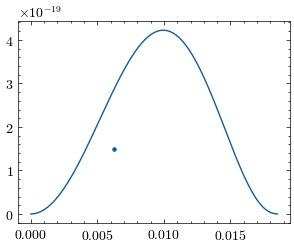

In [23]:
v_particles = np.zeros(n)

for i in tqdm(range(n)):
    v_particles[i] = sample_vel(radius_s[i], False)
    if i == n-1:     v_particles[i] = sample_vel(radius_s[i], True)
    

In [24]:
print(max(v_particles))

1.1244775906130096


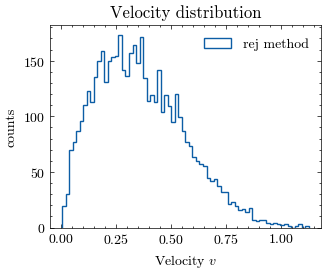

In [25]:
plt.figure()
plt.hist(v_particles, histtype = 'step', bins = int(np.sqrt(n)), label = 'rej method')
plt.xlabel("Velocity $v$")
plt.ylabel("counts")
plt.title("Velocity distribution")
plt.legend()
plt.show()

In [26]:
eps_particles = - (compute_potential(radius_s) + 0.5*v_particles**2)
print(min(eps_particles))

0.00013154325792121628


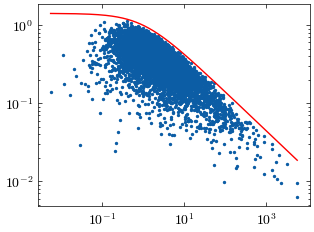

In [35]:
plt.plot(radius_s, np.sqrt(- 2 * compute_potential(radius_s)), c = 'r')
plt.scatter(radius_s, v_particles, s = 2)
plt.loglog()
plt.show()

In [36]:
P_theta_v = np.random.uniform(0, 1, n)
theta_v = np.arccos(1 - 2*P_theta_v)

P_phi_v = np.random.uniform(0, 1, n)
phi_v = 2 * np.pi * P_phi_v

vx, vy, vz = sph_to_carth (v_particles, theta_v, phi_v)

In [37]:
import datetime

def get_timestamp_filename():
    now = datetime.datetime.now()
    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
    return f"H_input_{timestamp}.txt"

In [38]:
filename = get_timestamp_filename()
print(filename)

H_input_2025-08-20_16-17-29.txt


In [39]:
inputf = open(filename, 'w')

particles_masses = ''
particles_positions = ''
particles_velocities = ''

for i in range(n):
    particles_masses = particles_masses + str(M/n) + '\n'
    particles_positions = particles_positions + str(x[i]) + ' ' + str(y[i]) + ' ' + str(z[i]) + '\n'
    particles_velocities = particles_velocities +  str(vx[i]) + ' ' + str(vy[i]) + ' ' + str(vz[i]) + '\n'

lines = [str(n) + '\n' + str(n_dim) + '\n0\n' + particles_masses + particles_positions + particles_velocities]
inputf.writelines(lines)

inputf.close()

In [40]:
volume = 4*np.pi/3 * a**3
softening = 0.1 * (volume / n)**(1/3)
print('suggested softening parameter = ', softening)

suggested softening parameter =  0.009426986134801155


In [41]:
def compute_rho(R):
    return M / (2* np.pi) * a/R * 1/(R+a)**3

In [42]:
sphere_density = compute_rho(a)
print('\nSphere density = ', sphere_density)

dyn_time = np.sqrt((3 * np.pi)/(16 *sphere_density))
print('\nDynamical time = ', dyn_time)

collapse_time = dyn_time * np.power(2, -1/2)

print('\nCollapse time = ', collapse_time)


Sphere density =  0.019894367886486918

Dynamical time =  5.441398092702653

Collapse time =  3.8476494904855922


In [52]:
folder = '../stellar_systems_dynamics2024/final_exercise/'
outname=filename.replace('input', 'output')
logname=filename.replace('input', 'log')

In [53]:
dtime = 0.05
tstop = 10
dtout = 0.1

In [54]:
command_line = ('./treecode in=' + folder + filename + ' out=' + folder + outname + 
                ' dtime=' + str(dtime) + ' eps=' + str(softening) + ' theta=0.5 tstop=' + str(tstop) + ' dtout=' + str(dtout) + ' > ' + logname)

In [55]:
print(command_line)

./treecode in=../stellar_systems_dynamics2024/final_exercise/H_input_2025-08-20_16-17-29.txt out=../stellar_systems_dynamics2024/final_exercise/H_output_2025-08-20_16-17-29.txt dtime=0.05 eps=0.009426986134801155 theta=0.5 tstop=10 dtout=0.1 > H_log_2025-08-20_16-17-29.txt
